In [1]:
import pandas as pd

df=pd.read_csv(r"C:\Users\33651\Desktop\ML_PROJECT\Fraud_detection\creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
import tensorflow as tf
import random
import numpy as np
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

In [3]:
df.columns


Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [4]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
from sklearn.model_selection import train_test_split

X=df.copy()
y=X.pop("Class")

X_train,X_valid,y_train,y_valid=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)


In [7]:
from sklearn.preprocessing import StandardScaler

num_col=["Time","Amount"]

scaler=StandardScaler()

X_train[num_col]=scaler.fit_transform(X_train[num_col])
X_valid[num_col]=scaler.transform(X_valid[num_col])


In [8]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    "balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {0: weights[0], 1: weights[1]}



In [9]:
from tensorflow import keras
from tensorflow.keras import layers

model=keras.Sequential([

    layers.Dense(units=128,activation="relu",input_shape=(X.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(64,activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(32,activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(1,activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
    keras.metrics.AUC(curve="PR", name="AUPRC"),
    "Precision",
    "Recall"
]
)



c:\Users\33651\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
early_stopping=keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
)

history=model.fit(
    X_train,y_train,validation_data=(X_valid,y_valid),
    epochs=50,batch_size=512,
    callbacks=[early_stopping]
)

Epoch 1/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUPRC: 0.2781 - Precision: 0.0143 - Recall: 0.6650 - loss: 0.2519 - val_AUPRC: 0.6515 - val_Precision: 0.7900 - val_Recall: 0.8061 - val_loss: 0.0257
Epoch 2/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUPRC: 0.5632 - Precision: 0.6534 - Recall: 0.6269 - loss: 0.0171 - val_AUPRC: 0.7047 - val_Precision: 0.8144 - val_Recall: 0.8061 - val_loss: 0.0099
Epoch 3/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUPRC: 0.6249 - Precision: 0.7767 - Recall: 0.6269 - loss: 0.0084 - val_AUPRC: 0.7037 - val_Precision: 0.8172 - val_Recall: 0.7755 - val_loss: 0.0058
Epoch 4/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUPRC: 0.6660 - Precision: 0.7961 - Recall: 0.6244 - loss: 0.0061 - val_AUPRC: 0.7211 - val_Precision: 0.8247 - val_Recall: 0.8163 - val_loss: 0.0045
Epoch 5/50
446/446 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUPRC: 0.7118 - Precision: 0.8523 - Recall: 0.6447 - loss: 0.0052 - val_AUPRC: 0.7169 - val_Precision: 0.8229 - val_Recall: 0.8061

Text(0.5, 1.0, 'Training vs validation AUPRC')

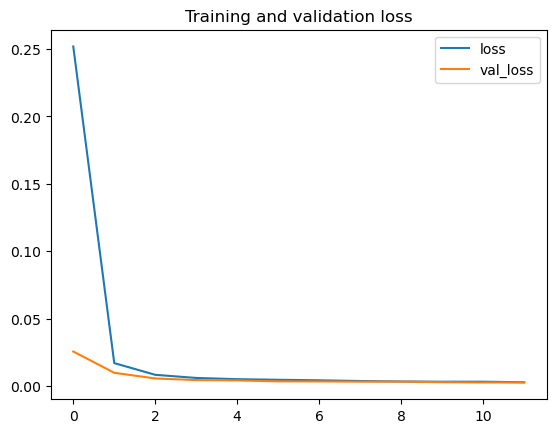

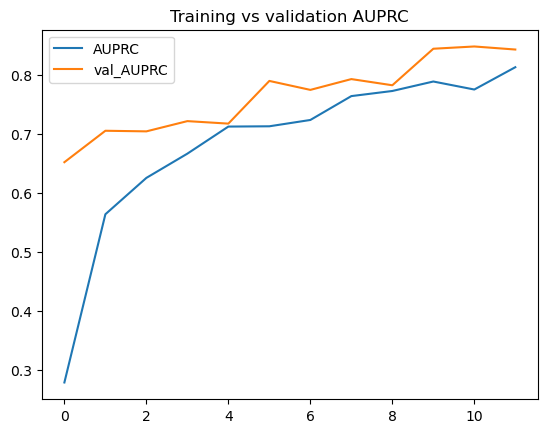

In [11]:
import matplotlib.pyplot as plt

history_df=pd.DataFrame(history.history)
history_df.loc[:,["loss","val_loss"]].plot()
plt.title("Training and validation loss")

history_df.loc[:,["AUPRC","val_AUPRC"]].plot()
plt.title("Training vs validation AUPRC")

In [12]:
from sklearn.metrics import classification_report, average_precision_score

y_pred_prob = model.predict(X_valid)

y_pred = (y_pred_prob > 0.5).astype(int)

auprc = average_precision_score(y_valid, y_pred_prob)

print(f"AUPRC : {auprc:.4f}\n")

print(classification_report(y_valid, y_pred))



1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 965us/step
AUPRC : 0.8121

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.80      0.83      0.81        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

